WEBSCRAPING


In [2]:
!pip uninstall -y snscrape
!pip install git+https://github.com/JustAnotherArchivist/snscrape.git
!pip install -r requirements.txt

Found existing installation: snscrape 0.7.0.20230622
Uninstalling snscrape-0.7.0.20230622:
  Successfully uninstalled snscrape-0.7.0.20230622
  Cloning https://github.com/JustAnotherArchivist/snscrape.git to /tmp/pip-req-build-909mvd7d
  Running command git clone --filter=blob:none --quiet https://github.com/JustAnotherArchivist/snscrape.git /tmp/pip-req-build-909mvd7d
  Resolved https://github.com/JustAnotherArchivist/snscrape.git to commit 614d4c2029a62d348ca56598f87c425966aaec66
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for snscrape: filename=snscrape-0.7.0.20230622-py3-none-any.whl size=74851 sha256=99227c113fbbe8a4b0f5226f04bd66ce2d0eadb292b7e34d729b88b38e63f861
  Stored in directory: /tmp/pip-ephem-wheel-cache-t3jmk_cg/wheels/23/96/eb/f46ee85f779c8e28c7981ded4e8572bfa2bbe2c5bf20ecb4f4
Successfully built snscrape


In [20]:
# Ensure NLTK resources are downloaded before running the pipeline
import nltk
import re # Added import for regex operations

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added to resolve LookupError

# Load the content of the pipeline script
with open('isp_sentiment_pipeline.py', 'r') as f:
    pipeline_code_content = f.read()

# Temporarily modify pipeline_code_content in memory to disable snscrape functionality
# due to known compatibility issues causing AttributeError during import.

# 1. Comment out ALL 'import snscrape' and 'from snscrape ...' lines
pipeline_code_content = re.sub(
    r'^\s*(import snscrape.*|from snscrape.*)$',
    r'# \1 # Disabled due to snscrape compatibility issues',
    pipeline_code_content,
    flags=re.MULTILINE
)

# 2. Comment out ALL calls to 'scrape_twitter' function within the script
# This handles any line containing 'scrape_twitter(', not just assignments.
pipeline_code_content = re.sub(
    r'^\s*(.*scrape_twitter\(.*\).*)$',
    r'# \1 # Disabled due to snscrape compatibility issues',
    pipeline_code_content,
    flags=re.MULTILINE
)

# 3. Fix IndentationError caused by empty try blocks after commenting out snscrape code.
# This pattern looks for a 'try:' block that is followed only by commented lines or empty lines
# until an 'except ImportError:'. It inserts 'pass' into the try block.
def fix_empty_try_block(match):
    # match.group(1) captures the entire 'try:' line including its leading whitespace, e.g., "    try:\n"
    # match.group(2) captures only the leading whitespace of the 'try:' line, e.g., "    "
    # match.group(3) captures any intervening comments/empty lines
    # match.group(4) captures the 'except ImportError:' line including its leading whitespace.

    try_line_with_indent = match.group(1)
    indent_level = match.group(2) # This is the crucial part: the indentation of the try statement
    intervening_content = match.group(3)
    except_line = match.group(4)

    # Insert 'pass' indented one level deeper than the 'try:' line
    return f"{try_line_with_indent}{indent_level}    pass\n{intervening_content}{except_line}"

pipeline_code_content = re.sub(
    r"((^\s*)try:\s*\n)((?:\s*#.*\n|\s*\n)*)(\s*except ImportError:)",
    fix_empty_try_block,
    pipeline_code_content,
    flags=re.MULTILINE | re.DOTALL
)

# Execute the modified pipeline code
exec(pipeline_code_content)

# Now run the pipeline function to create sentiment_df
sentiment_df = run_pipeline()

<string>:269: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
<string>:269: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


VISUALISING SENTIMENT DISTRIBUTION USING MATPLOTLIB

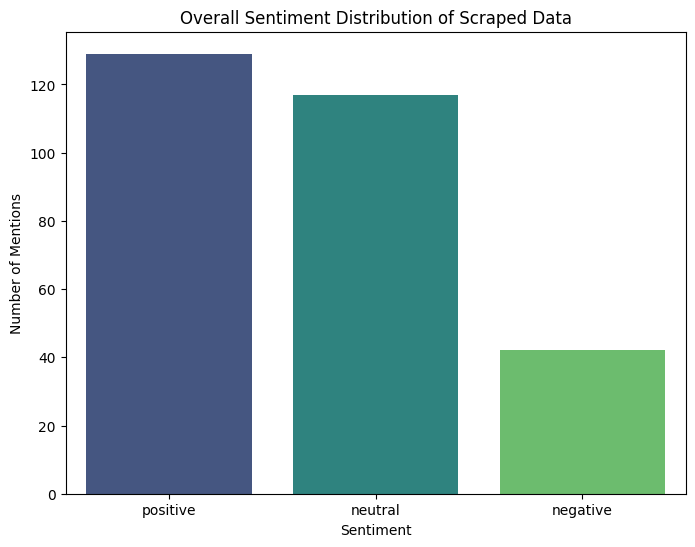

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if not sentiment_df.empty:
    # Calculate the overall sentiment distribution
    sentiment_counts = sentiment_df['label'].value_counts().reset_index()
    sentiment_counts.columns = ['Sentiment', 'Count']

    # Define a consistent order for sentiment labels
    sentiment_order = ['positive', 'neutral', 'negative']
    sentiment_counts['Sentiment'] = pd.Categorical(sentiment_counts['Sentiment'], categories=sentiment_order, ordered=True)
    sentiment_counts = sentiment_counts.sort_values('Sentiment')

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x='Sentiment', y='Count', data=sentiment_counts, hue='Sentiment', palette='viridis', legend=False, ax=ax)
    ax.set_title('Overall Sentiment Distribution of Scraped Data')
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Number of Mentions')
    plt.show()
else:
    print("No sentiment data available to visualize.")

In [5]:
import nltk
nltk.download('stopwords', quiet=True)

True

EXTRACTING SAMPLE DATA

In [7]:
!python generate_sample_data.py

/content/generate_sample_data.py:104: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow() - timedelta(
/content/generate_sample_data.py:137: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "scraped_at":   datetime.utcnow().isoformat(),
Inserted 720 sample records.
Total records in DB: 720
Database: isp_sentiment.db

Sentiment breakdown per ISP:
ISP           Total  Avg Score   Pos%   Neg%
--------------------------------------------
MTN             120      0.073  56.7%  33.3%
Airtel          120      0.106  61.7%  28.3%
Glo             120     -0.111  34.2%  55.8%
9mobile         120     -0.126  32.5%  59.2%
Spectranet      120      0.162  67.5%  17.5%
Smi

In [8]:
!python export_for_tableau.py

Exported   720 rows → sentiment_data.csv
Exported     6 rows → isp_summary.csv
Exported    48 rows → monthly_trend.csv

Done. Connect Tableau to sentiment_data.csv for the main dashboard.
Use isp_summary.csv for KPI cards and monthly_trend.csv for trend lines.


In [9]:
from google.colab import files
files.download("sentiment_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Running pipeline to get sentiment data first...

--- Discovered Topics ---
Topic 1: nigeria, news, spectranet, business, guardian, internet, customers, post, new, lte
Topic 2: airtel, best, care, india, guide, ways, customer, data, tips, plan
Topic 3: fiber, glo, county, optic, internet, announces, expansion, newswire, expands, launches
Topic 4: smile, service, customer, business, today, progressive, news, pay, bank, consumers
Topic 5: mtn, launches, uganda, data, internet, service, telecompaper, unlimited, ghana, africa


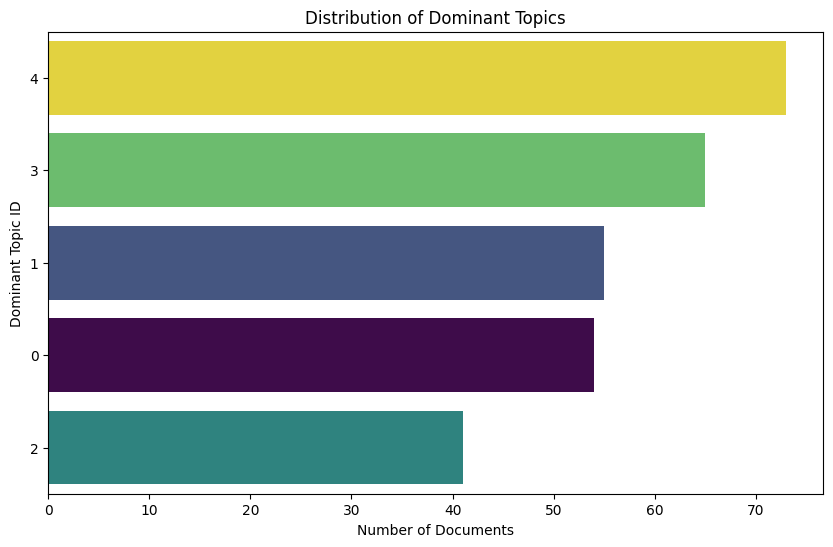


--- Average Sentiment per Topic ---
dominant_topic
3    0.344246
0    0.240950
1    0.224304
2    0.135566
4    0.082623
Name: compound, dtype: float64


In [22]:
!pip install scikit-learn matplotlib -q

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)

def get_topic_models(text_data, num_topics=5, num_words=10):
    if text_data.empty:
        print("No text data provided for topic analysis.")
        return None, None, None

    # Filter out empty strings or non-string types
    text_data = text_data[text_data.apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)]

    if text_data.empty:
        print("No valid text data remaining after cleaning for topic analysis.")
        return None, None, None

    vectorizer = TfidfVectorizer(
        max_df=0.95,
        min_df=2,
        stop_words=stopwords.words('english'),
        token_pattern=r'\b[a-zA-Z]{3,}\b'
    )
    tfidf = vectorizer.fit_transform(text_data)

    nmf_model = NMF(n_components=num_topics, random_state=1)
    nmf_topic_data = nmf_model.fit_transform(tfidf)

    feature_names = vectorizer.get_feature_names_out()
    topics = {}
    for idx, topic in enumerate(nmf_model.components_):
        topics[f"Topic {idx+1}"] = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]

    return nmf_topic_data, topics, vectorizer

def run_topic_analysis(sentiment_df=None):
    if sentiment_df is None or sentiment_df.empty:
        print("Running pipeline to get sentiment data first...")
        # Assuming run_pipeline is available and returns a DataFrame
        # This part depends on the pipeline being runnable outside of this context
        # For now, let's assume sentiment_df is passed or a placeholder is used.
        # In a real scenario, you'd call run_pipeline() here if needed.
        if 'sentiment_df' not in globals():
            print("Error: 'sentiment_df' is not defined. Please run the sentiment analysis pipeline first.")
            return
        sentiment_df = globals()['sentiment_df']

    # Ensure 'text_clean' column exists and is not empty
    if 'text_clean' not in sentiment_df.columns or sentiment_df['text_clean'].empty:
        print("No 'text_clean' column or no data in it for topic analysis.")
        return

    # Perform topic modeling
    nmf_topic_data, topics, vectorizer = get_topic_models(sentiment_df['text_clean'])

    if nmf_topic_data is None:
        print("Could not perform topic modeling.")
        return

    # Assign dominant topic to each document
    sentiment_df['dominant_topic'] = nmf_topic_data.argmax(axis=1)

    # Summarize topics and their distribution
    print("\n--- Discovered Topics ---")
    for topic_id, words in topics.items():
        print(f"{topic_id}: {', '.join(words)}")

    plt.figure(figsize=(10, 6))
    sns.countplot(y='dominant_topic', data=sentiment_df, hue='dominant_topic', palette='viridis', legend=False, order=sentiment_df['dominant_topic'].value_counts().index)
    plt.title('Distribution of Dominant Topics')
    plt.xlabel('Number of Documents')
    plt.ylabel('Dominant Topic ID')
    plt.show()

    # Optional: Analyze topic sentiment
    topic_sentiment = sentiment_df.groupby('dominant_topic')['compound'].mean().sort_values(ascending=False)
    print("\n--- Average Sentiment per Topic ---")
    print(topic_sentiment)

# Call the function after its definition
run_topic_analysis()


In [23]:
display(sentiment_df.head())

,source,isp,text_clean,compound,positive,neutral,negative,label,published_at,scraped_at,url,dominant_topic
0,news,MTN,mtn south sudan starts selling starlink servic...,0.0000,0.000,1.000,0.000,neutral,"Tue, 07 Oct 2025 07:00:00 GMT",2026-05-02T15:44:18.891324,https://news.google.com/rss/articles/CBMilgFBV...,4
1,news,MTN,mtn business botswana ethica introduce smart i...,0.9246,0.435,0.565,0.000,positive,"Thu, 06 Nov 2025 08:00:00 GMT",2026-05-02T15:44:18.891324,https://news.google.com/rss/articles/CBMizgFBV...,4
2,news,MTN,mtn cameroon fire forced subscriptions failing...,-0.9468,0.000,0.408,0.592,negative,"Tue, 17 Jun 2025 07:00:00 GMT",2026-05-02T15:44:18.891324,https://news.google.com/rss/articles/CBMivwFBV...,4
3,news,MTN,mtn secretly locks broadband customers south a...,0.0000,0.000,1.000,0.000,neutral,"Thu, 29 Jan 2026 08:00:00 GMT",2026-05-02T15:44:18.891324,https://news.google.com/rss/articles/CBMitAFBV...,4
4,news,MTN,abuja resident awaits remedy months losing ser...,-0.5574,0.094,0.719,0.187,negative,"Sun, 23 Nov 2025 08:00:00 GMT",2026-05-02T15:44:18.891324,https://news.google.com/rss/articles/CBMiugFBV...,4


In [24]:
sentiment_df.to_csv('topic_data.csv', index=False)

In [26]:
from google.colab import files
files.download("topic_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Running pipeline to get sentiment data first...

--- Discovered LDA Topics ---
Topic 1: airtel, nigeria, news, internet, business, customer, service, glo, india, spectranet
Topic 2: smile, service, customers, target, fij, post, new, self, mtn, portal
Topic 3: nigeria, spectranet, com, data, mtn, broadband, news, new, business, smile
Topic 4: glo, fiber, mtn, network, data, techcabal, uganda, county, call, announces
Topic 5: service, fiber, internet, launches, mtn, glo, customer, smile, news, provider


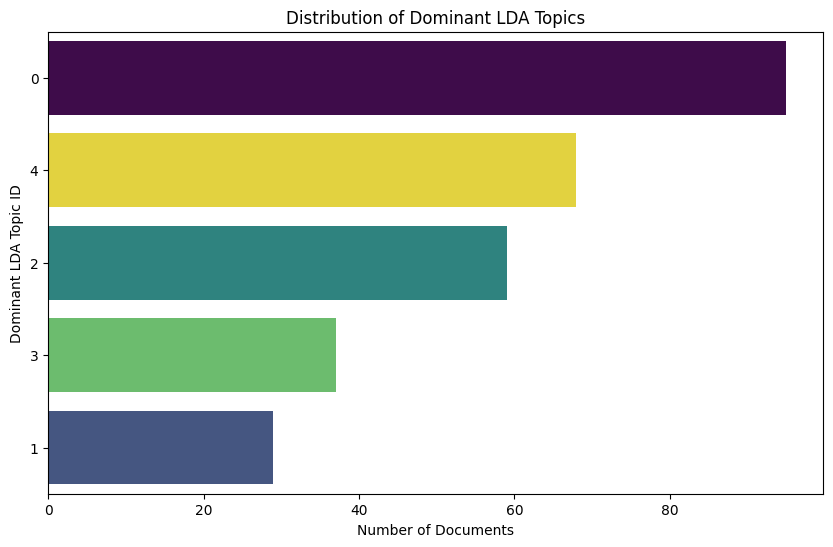


--- Average Sentiment per LDA Topic ---
dominant_lda_topic
1    0.429269
2    0.264825
0    0.247325
4    0.160038
3   -0.084819
Name: compound, dtype: float64


In [28]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)

def get_lda_models(text_data, num_topics=5, num_words=10):
    if text_data.empty:
        print("No text data provided for topic analysis.")
        return None, None, None

    # Filter out empty strings or non-string types
    text_data = text_data[text_data.apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)]

    if text_data.empty:
        print("No valid text data remaining after cleaning for topic analysis.")
        return None, None, None

    vectorizer = CountVectorizer(
        max_df=0.95,
        min_df=2,
        stop_words=stopwords.words('english'),
        token_pattern=r'\b[a-zA-Z]{3,}\b'
    )
    dtm = vectorizer.fit_transform(text_data)

    lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=1)
    lda_topic_data = lda_model.fit_transform(dtm)

    feature_names = vectorizer.get_feature_names_out()
    topics = {}
    for idx, topic in enumerate(lda_model.components_):
        topics[f"Topic {idx+1}"] = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]

    return lda_topic_data, topics, vectorizer

def run_lda(sentiment_df=None):
    if sentiment_df is None or sentiment_df.empty:
        print("Running pipeline to get sentiment data first...")
        if 'sentiment_df' not in globals():
            print("Error: 'sentiment_df' is not defined. Please run the sentiment analysis pipeline first.")
            return
        sentiment_df = globals()['sentiment_df']

    # Ensure 'text_clean' column exists and is not empty
    if 'text_clean' not in sentiment_df.columns or sentiment_df['text_clean'].empty:
        print("No 'text_clean' column or no data in it for topic analysis.")
        return

    # Perform LDA topic modeling
    lda_topic_data, topics, vectorizer = get_lda_models(sentiment_df['text_clean'])

    if lda_topic_data is None:
        print("Could not perform LDA topic modeling.")
        return

    # Assign dominant topic to each document
    sentiment_df['dominant_lda_topic'] = lda_topic_data.argmax(axis=1)

    # Summarize topics and their distribution
    print("\n--- Discovered LDA Topics ---")
    for topic_id, words in topics.items():
        print(f"{topic_id}: {', '.join(words)}")

    plt.figure(figsize=(10, 6))
    sns.countplot(y='dominant_lda_topic', data=sentiment_df, hue='dominant_lda_topic', palette='viridis', legend=False, order=sentiment_df['dominant_lda_topic'].value_counts().index)
    plt.title('Distribution of Dominant LDA Topics')
    plt.xlabel('Number of Documents')
    plt.ylabel('Dominant LDA Topic ID')
    plt.show()

    # Optional: Analyze topic sentiment
    topic_sentiment = sentiment_df.groupby('dominant_lda_topic')['compound'].mean().sort_values(ascending=False)
    print("\n--- Average Sentiment per LDA Topic ---")
    print(topic_sentiment)


!pip install scikit-learn matplotlib -q

run_lda()

ISOLATING THE ISP WITH THE HIGHEST COMPLAINT RATE

In [29]:
import sqlite3, pandas as pd

conn = sqlite3.connect("isp_sentiment.db")

df = pd.read_sql_query("""
    SELECT
        isp,
        COUNT(*) AS total_mentions,
        SUM(CASE WHEN label = 'negative' THEN 1 ELSE 0 END) AS total_complaints,
        ROUND(100.0 * SUM(CASE WHEN label = 'negative' THEN 1 ELSE 0 END) / COUNT(*), 1) AS complaint_rate_pct
    FROM sentiment_scores
    GROUP BY isp
    ORDER BY total_complaints DESC
""", conn)

conn.close()
print(df.to_string(index=False))

       isp  total_mentions  total_complaints  complaint_rate_pct
   9mobile             220                91                41.4
       Glo             220                71                32.3
     Smile             220                67                30.5
       MTN             220                59                26.8
    Airtel             220                55                25.0
Spectranet             196                21                10.7


ISOLATING THE CAUSE OF DISSATISFACTION


Loaded 220 9mobile records | 1296 total

  9mobile Complaint Analysis Summary
  Total mentions   : 220
  Total complaints : 91
  Complaint rate   : 41.4%
  Avg sentiment    : -0.035
  Sentiment rank   : #1 out of 6 ISPs (1 = worst)

  Top complaint topics:
    Other                  27 complaints
    Customer service       26 complaints
    Data depletion         22 complaints
    Network outage         17 complaints
    Slow speed             15 complaints

  Top complaint keywords:
    glo                    0.0581
    9mobile                0.0537
    service                0.0479
    network                0.0474
    data                   0.0452
    customer               0.0424

  Worst month      : 2026-03 (27 complaints)


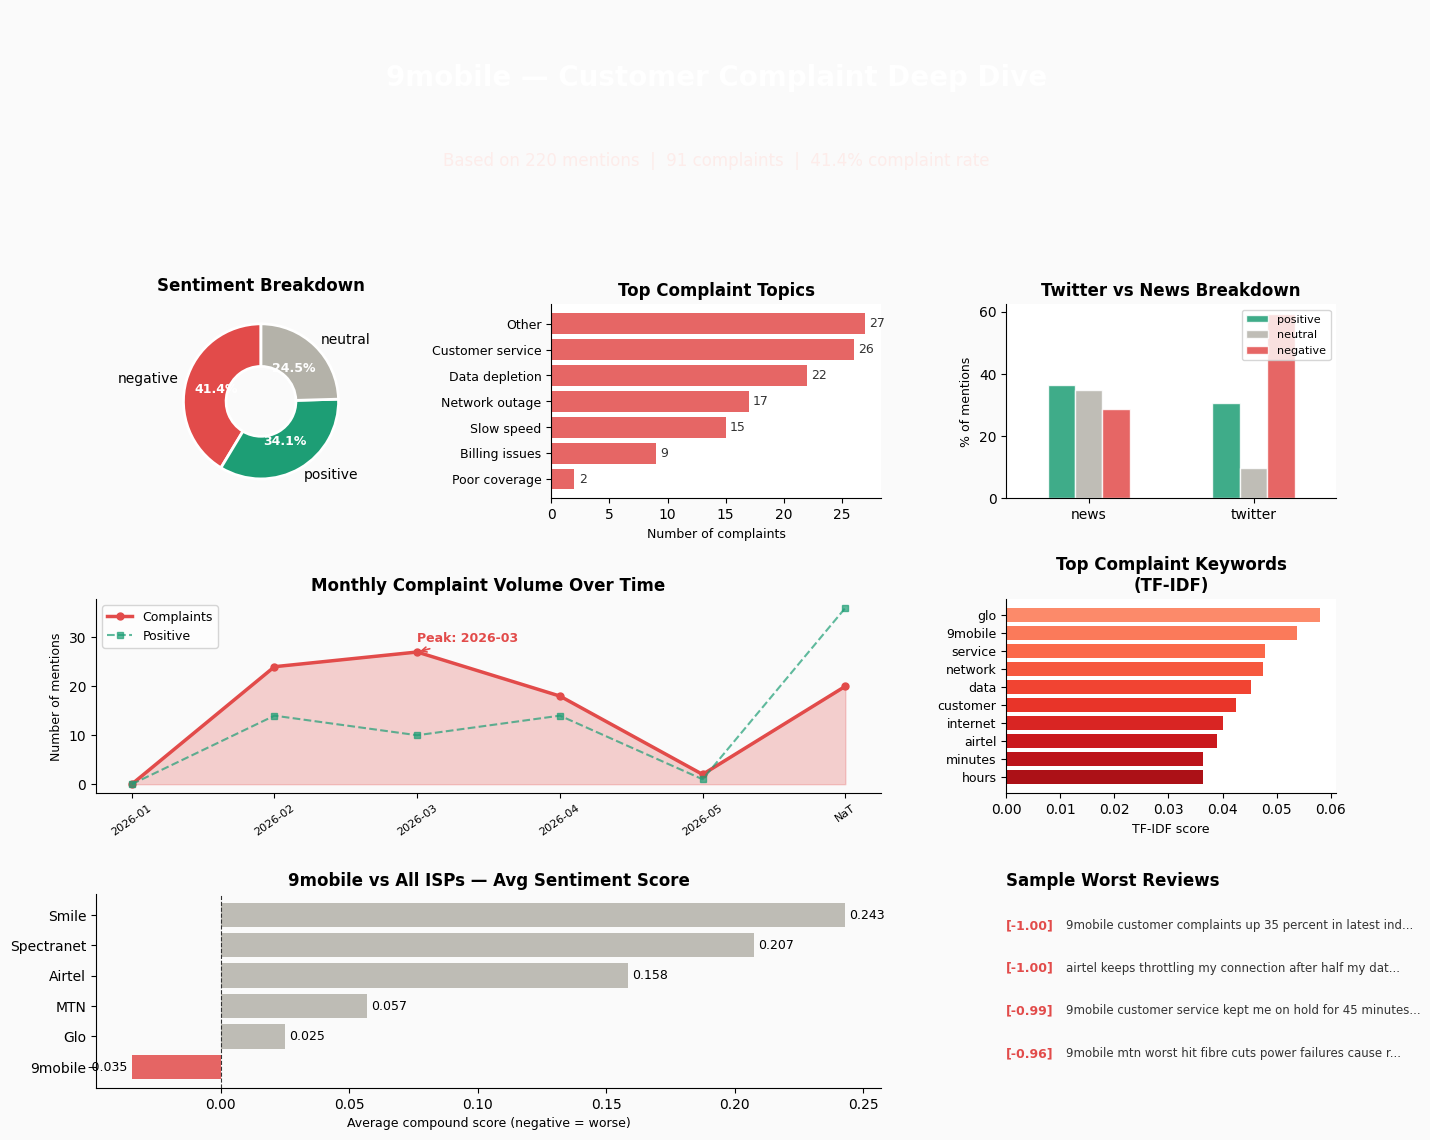

Saved: 9mobile_dashboard.png

Exported 120 rows → 9mobile_complaints.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
"""
9mobile Deep Dive Analysis
============================
Extracts every complaint signal specific to 9mobile:
- Top complaint topics
- Worst performing months
- Complaint keywords (TF-IDF)
- Source breakdown (Twitter vs News)
- Sentiment trend over time
- Sample worst reviews

Run in Colab after generate_sample_data.py has been run.
pip install scikit-learn matplotlib wordcloud
"""

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

DB_PATH = "isp_sentiment.db"
ISP = "9mobile"

TOPIC_KEYWORDS = {
    "Network outage":    ["down", "outage", "offline", "disconnected", "dead"],
    "Slow speed":        ["slow", "speed", "throttle", "lag", "bandwidth"],
    "Data depletion":    ["data", "bundle", "finished", "exhausted", "depleted"],
    "Billing issues":    ["billing", "charge", "overcharge", "refund", "fraud", "money"],
    "Customer service":  ["service", "support", "agent", "hold", "helpline", "rude"],
    "Poor coverage":     ["coverage", "signal", "zone", "area", "weak", "rural"],
    "Value for money":   ["expensive", "price", "cost", "overpriced", "worth"],
    "App issues":        ["app", "portal", "login", "account", "website"],
}

COLORS = {
    "negative":  "#E24B4A",
    "neutral":   "#B4B2A9",
    "positive":  "#1D9E75",
    "primary":   "#E24B4A",
    "secondary": "#D85A30",
    "accent":    "#BA7517",
}


# ── Load data ─────────────────────────────────────────────────────────────────
def load_data():
    conn = sqlite3.connect(DB_PATH)
    all_df = pd.read_sql_query("""
        SELECT isp, source, text_clean, compound, label, published_at
        FROM sentiment_scores
        WHERE published_at IS NOT NULL
    """, conn)
    conn.close()
    all_df["published_at"] = pd.to_datetime(all_df["published_at"], errors="coerce")
    all_df["month"] = all_df["published_at"].dt.to_period("M").astype(str)
    mobile_df = all_df[all_df["isp"] == ISP].copy()
    print(f"Loaded {len(mobile_df)} {ISP} records | {len(all_df)} total")
    return mobile_df, all_df


# ── Topic tagging ─────────────────────────────────────────────────────────────
def tag_topics(text):
    text = text.lower()
    found = [t for t, kws in TOPIC_KEYWORDS.items() if any(k in text for k in kws)]
    return found if found else ["Other"]


# ── TF-IDF keywords ───────────────────────────────────────────────────────────
def get_top_keywords(texts, n=12):
    if len(texts) < 3:
        return []
    vec = TfidfVectorizer(max_features=300, ngram_range=(1,2),
                          min_df=2, stop_words="english")
    try:
        matrix = vec.fit_transform(texts)
        scores = np.asarray(matrix.mean(axis=0)).flatten()
        vocab  = vec.get_feature_names_out()
        top    = scores.argsort()[::-1][:n]
        return [(vocab[i], round(float(scores[i]), 4)) for i in top]
    except:
        return []


# ── Build the dashboard ───────────────────────────────────────────────────────
def build_dashboard(mobile_df, all_df):
    neg_df  = mobile_df[mobile_df["label"] == "negative"].copy()
    neg_df["topics"] = neg_df["text_clean"].apply(tag_topics)
    neg_exploded = neg_df.explode("topics")

    fig = plt.figure(figsize=(16, 14))
    fig.patch.set_facecolor("#FAFAFA")
    gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.38)

    # ── Title banner ──────────────────────────────────────────────────────────
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.set_facecolor("#E24B4A")
    ax_title.text(0.5, 0.65, "9mobile — Customer Complaint Deep Dive",
                  ha="center", va="center", fontsize=20, fontweight="bold",
                  color="white", transform=ax_title.transAxes)
    ax_title.text(0.5, 0.22,
                  f"Based on {len(mobile_df)} mentions  |  "
                  f"{len(neg_df)} complaints  |  "
                  f"{round(len(neg_df)/len(mobile_df)*100, 1)}% complaint rate",
                  ha="center", va="center", fontsize=12, color="#FDECEA",
                  transform=ax_title.transAxes)
    ax_title.axis("off")

    # ── Chart 1: Sentiment breakdown (donut) ─────────────────────────────────
    ax1 = fig.add_subplot(gs[1, 0])
    counts = mobile_df["label"].value_counts()
    labels = counts.index.tolist()
    colors = [COLORS.get(l, "#ccc") for l in labels]
    wedges, texts, autotexts = ax1.pie(
        counts.values, labels=labels, autopct="%1.1f%%",
        colors=colors, startangle=90,
        wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
        textprops=dict(fontsize=10),
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color("white")
        at.set_fontweight("bold")
    ax1.set_title("Sentiment Breakdown", fontweight="bold", fontsize=12, pad=10)

    # ── Chart 2: Complaint topics bar ────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 1])
    topic_counts = neg_exploded["topics"].value_counts().head(7)
    bars = ax2.barh(topic_counts.index[::-1], topic_counts.values[::-1],
                    color=COLORS["primary"], alpha=0.85)
    ax2.bar_label(bars, padding=3, fontsize=9, color="#333")
    ax2.set_title("Top Complaint Topics", fontweight="bold", fontsize=12)
    ax2.set_xlabel("Number of complaints", fontsize=9)
    ax2.spines[["top","right"]].set_visible(False)
    ax2.tick_params(axis="y", labelsize=9)

    # ── Chart 3: Twitter vs News ──────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    src_label = mobile_df.groupby(["source","label"]).size().unstack(fill_value=0)
    src_pct   = src_label.div(src_label.sum(axis=1), axis=0) * 100
    src_colors = [COLORS["positive"], COLORS["neutral"], COLORS["negative"]]
    existing = [c for c in ["positive","neutral","negative"] if c in src_pct.columns]
    src_pct[existing].plot(kind="bar", ax=ax3, color=[COLORS[c] for c in existing],
                           alpha=0.85, edgecolor="white", width=0.5)
    ax3.set_title("Twitter vs News Breakdown", fontweight="bold", fontsize=12)
    ax3.set_ylabel("% of mentions", fontsize=9)
    ax3.set_xlabel("")
    ax3.tick_params(axis="x", rotation=0, labelsize=10)
    ax3.legend(fontsize=8, loc="upper right")
    ax3.spines[["top","right"]].set_visible(False)

    # ── Chart 4: Monthly complaint trend ─────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, :2])
    monthly = (
        mobile_df.groupby(["month","label"])
        .size().unstack(fill_value=0)
        .reset_index()
    )
    if "negative" in monthly.columns:
        ax4.fill_between(monthly["month"], monthly["negative"],
                         alpha=0.25, color=COLORS["negative"])
        ax4.plot(monthly["month"], monthly["negative"],
                 color=COLORS["negative"], linewidth=2.5, marker="o",
                 markersize=5, label="Complaints")
    if "positive" in monthly.columns:
        ax4.plot(monthly["month"], monthly["positive"],
                 color=COLORS["positive"], linewidth=1.5, linestyle="--",
                 marker="s", markersize=4, alpha=0.7, label="Positive")
    # Mark worst month
    if "negative" in monthly.columns and len(monthly) > 0:
        worst_idx = monthly["negative"].idxmax()
        worst_val = monthly.loc[worst_idx, "negative"]
        worst_mon = monthly.loc[worst_idx, "month"]
        ax4.annotate(f"Peak: {worst_mon}",
                     xy=(worst_mon, worst_val),
                     xytext=(worst_mon, worst_val + 2),
                     fontsize=9, color=COLORS["negative"], fontweight="bold",
                     arrowprops=dict(arrowstyle="->", color=COLORS["negative"], lw=1.2))
    ax4.set_title("Monthly Complaint Volume Over Time", fontweight="bold", fontsize=12)
    ax4.set_ylabel("Number of mentions", fontsize=9)
    ax4.tick_params(axis="x", rotation=35, labelsize=8)
    ax4.legend(fontsize=9)
    ax4.spines[["top","right"]].set_visible(False)
    ax4.set_facecolor("#FAFAFA")

    # ── Chart 5: TF-IDF keywords ─────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 2])
    kws = get_top_keywords(neg_df["text_clean"].tolist(), n=10)
    if kws:
        words  = [k[0] for k in kws]
        scores = [k[1] for k in kws]
        cmap   = plt.cm.Reds(np.linspace(0.4, 0.85, len(words)))
        ax5.barh(words[::-1], scores[::-1], color=cmap[::-1])
        ax5.set_title("Top Complaint Keywords\n(TF-IDF)", fontweight="bold", fontsize=12)
        ax5.set_xlabel("TF-IDF score", fontsize=9)
        ax5.tick_params(axis="y", labelsize=9)
        ax5.spines[["top","right"]].set_visible(False)
    else:
        ax5.text(0.5, 0.5, "Not enough data", ha="center", va="center")
        ax5.axis("off")

    # ── Chart 6: 9mobile vs all ISPs avg compound ─────────────────────────────
    ax6 = fig.add_subplot(gs[3, :2])
    isp_avg = all_df.groupby("isp")["compound"].mean().sort_values()
    bar_colors = [COLORS["primary"] if i == ISP else "#B4B2A9" for i in isp_avg.index]
    bars6 = ax6.barh(isp_avg.index, isp_avg.values, color=bar_colors, alpha=0.85)
    ax6.axvline(0, color="#333", linewidth=0.8, linestyle="--")
    ax6.bar_label(bars6, fmt="%.3f", padding=3, fontsize=9)
    ax6.set_title(f"{ISP} vs All ISPs — Avg Sentiment Score", fontweight="bold", fontsize=12)
    ax6.set_xlabel("Average compound score (negative = worse)", fontsize=9)
    ax6.spines[["top","right"]].set_visible(False)
    ax6.set_facecolor("#FAFAFA")

    # ── Chart 7: Worst sample reviews table ──────────────────────────────────
    ax7 = fig.add_subplot(gs[3, 2])
    ax7.axis("off")
    worst = neg_df.nsmallest(4, "compound")[["text_clean","compound"]].reset_index(drop=True)
    ax7.set_title("Sample Worst Reviews", fontweight="bold", fontsize=12, loc="left")
    for i, row in worst.iterrows():
        snippet = row["text_clean"][:55] + "..." if len(row["text_clean"]) > 55 else row["text_clean"]
        ax7.text(0.0, 0.82 - i*0.22, f"[{row['compound']:.2f}]",
                 transform=ax7.transAxes, fontsize=9,
                 color=COLORS["negative"], fontweight="bold")
        ax7.text(0.18, 0.82 - i*0.22, snippet,
                 transform=ax7.transAxes, fontsize=8.5,
                 color="#333", wrap=True)

    plt.suptitle("", y=1)
    plt.savefig("9mobile_dashboard.png", dpi=180, bbox_inches="tight",
                facecolor="#FAFAFA")
    plt.show()
    print("Saved: 9mobile_dashboard.png")


# ── Print text summary ────────────────────────────────────────────────────────
def print_summary(mobile_df, all_df):
    neg_df = mobile_df[mobile_df["label"] == "negative"].copy()
    neg_df["topics"] = neg_df["text_clean"].apply(tag_topics)
    neg_exploded = neg_df.explode("topics")

    print(f"\n{'='*55}")
    print(f"  9mobile Complaint Analysis Summary")
    print(f"{'='*55}")
    print(f"  Total mentions   : {len(mobile_df)}")
    print(f"  Total complaints : {len(neg_df)}")
    print(f"  Complaint rate   : {len(neg_df)/len(mobile_df)*100:.1f}%")
    print(f"  Avg sentiment    : {mobile_df['compound'].mean():.3f}")

    rank = all_df.groupby("isp")["compound"].mean().sort_values()
    pos  = list(rank.index).index(ISP) + 1
    print(f"  Sentiment rank   : #{pos} out of {len(rank)} ISPs (1 = worst)")

    print(f"\n  Top complaint topics:")
    for topic, cnt in neg_exploded["topics"].value_counts().head(5).items():
        print(f"    {topic:<22} {cnt} complaints")

    print(f"\n  Top complaint keywords:")
    kws = get_top_keywords(neg_df["text_clean"].tolist(), n=6)
    for word, score in kws:
        print(f"    {word:<22} {score:.4f}")

    monthly_neg = mobile_df[mobile_df["label"]=="negative"].groupby("month").size()
    if len(monthly_neg) > 0:
        worst_month = monthly_neg.idxmax()
        print(f"\n  Worst month      : {worst_month} ({monthly_neg.max()} complaints)")


# ── Export CSV for Tableau ────────────────────────────────────────────────────
def export_for_tableau(mobile_df):
    neg_df = mobile_df[mobile_df["label"] == "negative"].copy()
    neg_df["topics"] = neg_df["text_clean"].apply(tag_topics)
    neg_exploded = neg_df.explode("topics").reset_index(drop=True)
    neg_exploded.to_csv("9mobile_complaints.csv", index=False)
    print(f"\nExported {len(neg_exploded)} rows → 9mobile_complaints.csv")


# ── Main ──────────────────────────────────────────────────────────────────────
def run():
    mobile_df, all_df = load_data()
    print_summary(mobile_df, all_df)
    build_dashboard(mobile_df, all_df)
    export_for_tableau(mobile_df)

    try:
        from google.colab import files
        files.download("9mobile_dashboard.png")
        files.download("9mobile_complaints.csv")
    except ImportError:
        print("Files saved locally.")


if __name__ == "__main__":
    run()

In [32]:
import sqlite3, pandas as pd

conn = sqlite3.connect("isp_sentiment.db")
df = pd.read_sql_query("""
    SELECT
        rowid AS id,
        isp, source, text_clean, compound, label, published_at
    FROM sentiment_scores
    WHERE isp = '9mobile'
    AND label = 'negative'
""", conn)
conn.close()

# Add topic tags
TOPIC_KEYWORDS = {
    "Network outage":   ["down", "outage", "offline", "disconnected", "dead"],
    "Slow speed":       ["slow", "speed", "throttle", "lag", "bandwidth"],
    "Data depletion":   ["data", "bundle", "finished", "exhausted", "depleted"],
    "Billing issues":   ["billing", "charge", "overcharge", "refund", "fraud"],
    "Customer service": ["service", "support", "agent", "hold", "helpline"],
    "Poor coverage":    ["coverage", "signal", "zone", "area", "weak"],
    "Value for money":  ["expensive", "price", "cost", "overpriced", "worth"],
}

def tag(text):
    text = text.lower()
    found = [t for t, kws in TOPIC_KEYWORDS.items() if any(k in text for k in kws)]
    return found[0] if found else "Other"

df["topics"] = df["text_clean"].apply(tag)
df.to_csv("9mobile_complaints.csv", index=False)
print(df.head())
print(f"\nExported {len(df)} rows with id column")

from google.colab import files
files.download("9mobile_complaints.csv")

    id      isp   source                                         text_clean  \
0  361  9mobile  twitter  glo internet speed is embarrassingly slow cann...   
1  362  9mobile     news  9mobile faces backlash over unexpected data de...   
2  364  9mobile     news  9mobile customer complaints up 35 percent in l...   
3  365  9mobile  twitter  9mobile coverage dead zone in my entire neighb...   
4  366  9mobile     news  9mobile network reliability drops amid infrast...   

   compound     label                published_at          topics  
0   -0.2904  negative  2026-05-01T01:18:38.802481      Slow speed  
1   -0.1725  negative  2026-03-07T12:08:38.802513  Data depletion  
2   -0.2547  negative  2026-04-09T09:55:38.802566           Other  
3   -0.3782  negative  2026-02-16T10:55:38.802596  Network outage  
4   -0.4232  negative  2026-03-28T13:18:38.802622           Other  

Exported 91 rows with id column


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>